# TP3 - Template Matching

Objetivo: detectar el logo de Coca-Cola en las imágenes provistas utilizando un único template.

Se resuelven los tres puntos de la consigna:

1. Una detección por imagen, evitando falsos positivos.
2. Múltiples detecciones en `coca_multi.png`.
3. Generalización del detector a todas las imágenes.

En cada caso se muestran **bounding boxes** y el **nivel de confianza**.




# Alumnos:

## - Ignacio Rubiolo
## - Lourdes Tolotto

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGES_DIR = Path("resources/images")
TEMPLATE_DIR = Path("resources/template")


## 1. Carga de datos


In [2]:
image_paths = sorted([
    p for p in IMAGES_DIR.iterdir()
    if p.suffix.lower() in {".png", ".jpg", ".jpeg"}
])

template_path = TEMPLATE_DIR / "pattern.png"
template = cv2.imread(str(template_path))

print("Imágenes:")
for p in image_paths:
    print(" -", p.name)

print("\nTemplate:")
print(" -", template_path.name)


Imágenes:
 - COCA-COLA-LOGO.jpg
 - coca_logo_1.png
 - coca_logo_2.png
 - coca_multi.png
 - coca_retro_1.png
 - coca_retro_2.png
 - logo_1.png

Template:
 - pattern.png


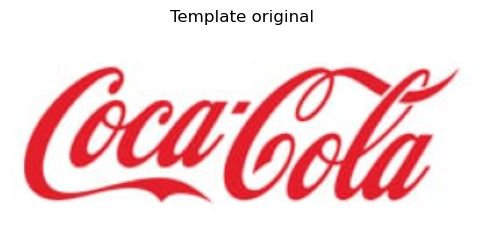

In [3]:
plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))
plt.title("Template original")
plt.axis("off")
plt.show()


## 2. Preparación del template

Se elimina el margen blanco del template para conservar principalmente la región que contiene el logo.


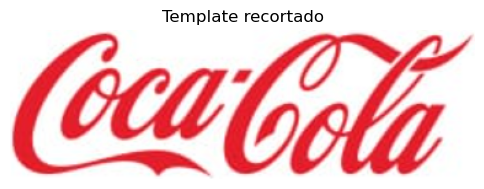

In [4]:
gray_template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

mask = (gray_template < 250).astype(np.uint8)
x, y, w, h = cv2.boundingRect(mask)

template = template[y:y+h, x:x+w]

plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))
plt.title("Template recortado")
plt.axis("off")
plt.show()


## 3. Preprocesamiento y parámetros


In [5]:
def preprocess_single(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    gradient = cv2.magnitude(gx, gy)

    gradient = cv2.normalize(
        gradient,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return gradient


def preprocess_multi(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.GaussianBlur(gray, (3, 3), 0)

# Para imágenes donde el logo puede ser grande
SCALES_SINGLE = np.linspace(0.4, 3.2, 60)

# Para coca_multi.png, donde aparecen logos más pequeños
SCALES_MULTI = np.linspace(0.15, 1.0, 30)

THRESHOLD_MULTI = 0.36
NMS_THRESHOLD = 0.30


La búsqueda se hace en varias escalas porque el logo no aparece siempre con el mismo tamaño.


## Punto 1 - Una detección por imagen


In [ ]:
def detect_one(
    image,
    template,
    scales=SCALES_SINGLE
):
    image_proc = preprocess_single(image)
    template_proc = preprocess_single(template)

    best_score = -1
    best_box = None
    best_scale = None

    for scale in scales:

        # Redimensionamos el template según la escala actual
        resized = cv2.resize(
            template_proc,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
        )

        h, w = resized.shape

        # Omitimos escalas que resulten en un template demasiado pequeño o demasiado grande
        if h < 5 or w < 5:
            continue

        if h >= image_proc.shape[0] or w >= image_proc.shape[1]:
            continue

        # Aplicamos la correlación normalizada entre la imagen y el template redimensionado
        response = cv2.matchTemplate(
            image_proc,
            resized,
            cv2.TM_CCOEFF_NORMED
        )

        # Obtenemos la ubicación y el score máximo de la respuesta
        _, score, _, location = cv2.minMaxLoc(response)

        # Guardamos la mejor detección hasta ahora
        if score > best_score:
            x, y = location

            best_score = score
            best_box = (x, y, x + w, y + h)
            best_scale = scale

    return best_box, best_score, best_scale

In [7]:
def show_one_detection(image, box, score, title):
    out = image.copy()

    if box is not None:
        x1, y1, x2, y2 = box

        cv2.rectangle(
            out,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            out,
            f"{score:.2f}",
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


COCA-COLA-LOGO.jpg   | score = 0.217 | scale = 3.15


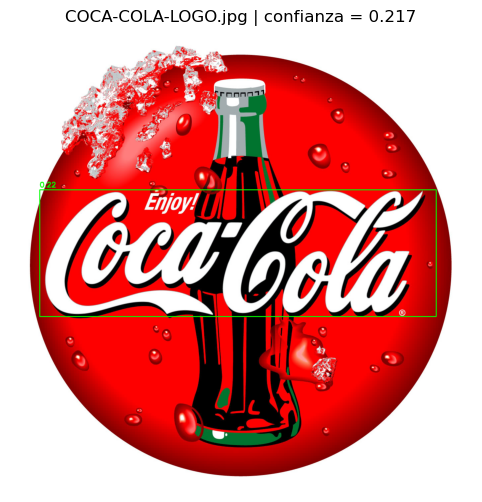

coca_logo_1.png      | score = 0.447 | scale = 0.45


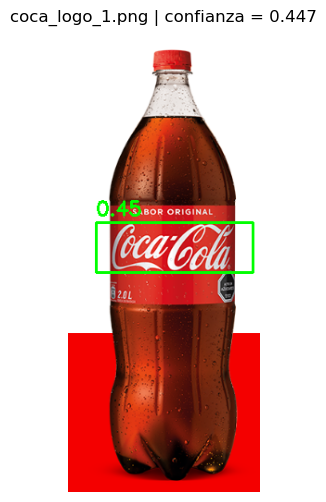

coca_logo_2.png      | score = 0.214 | scale = 0.59


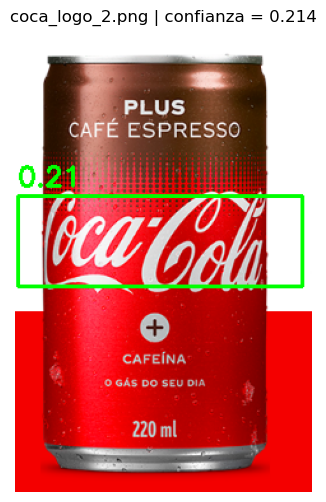

coca_retro_1.png     | score = 0.374 | scale = 1.35


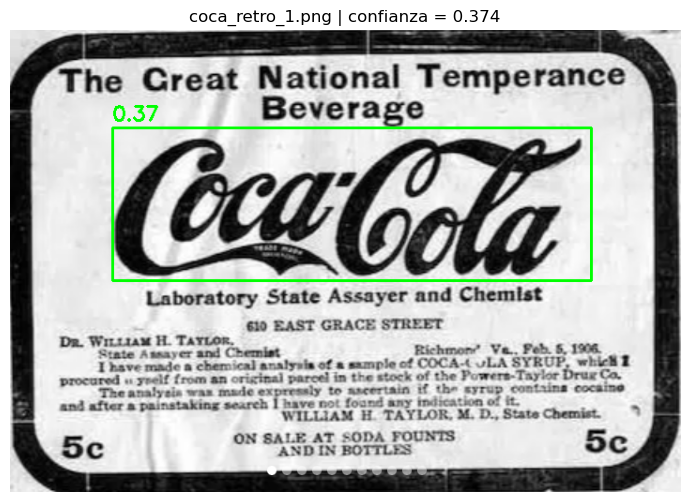

coca_retro_2.png     | score = 0.426 | scale = 0.40


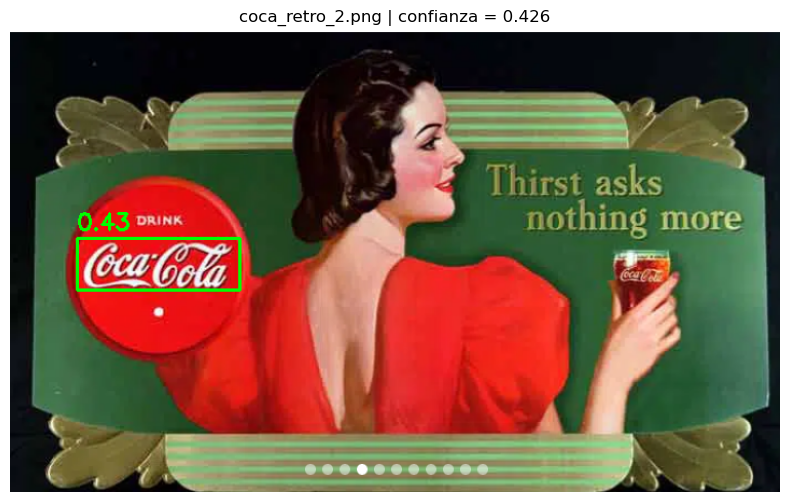

logo_1.png           | score = 0.304 | scale = 0.78


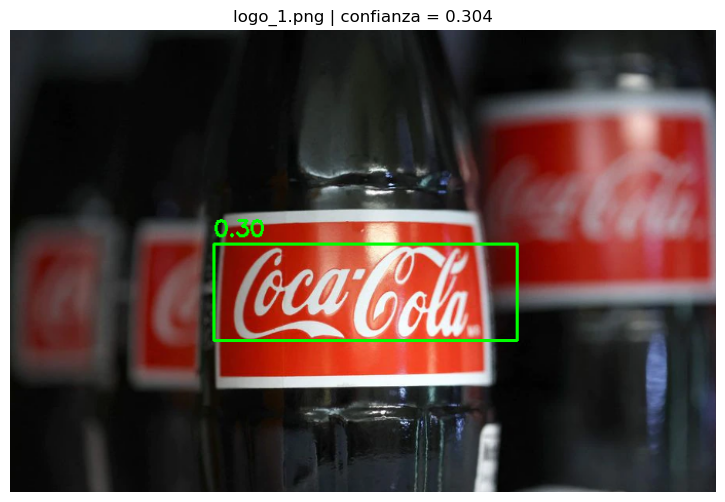

In [ ]:
single_results = []

for path in image_paths:
    # Omitimos coca_multi.png, que se procesa en otro bloque
    if path.name == "coca_multi.png":
        continue

    image = cv2.imread(str(path))

    # Detectamos el logo en la imagen
    box, score, scale = detect_one(
        image,
        template
    )

    single_results.append({
        "image": path.name,
        "score": score,
        "scale": scale
    })

    print(
        f"{path.name:20s} | "
        f"score = {score:.3f} | "
        f"scale = {scale:.2f}"
    )

    show_one_detection(
        image,
        box,
        score,
        title=f"{path.name} | confianza = {score:.3f}"
    )


## Punto 2 - Múltiples detecciones en `coca_multi.png`


In [ ]:
def detect_multiple(
    image,
    template,
    threshold,
    scales,
    nms_threshold=0.30
):
    image_proc = preprocess_multi(image)
    template_proc = preprocess_multi(template)

    boxes = []
    scores = []

    # Iteramos sobre las escalas para detectar múltiples instancias del logo
    for scale in scales:

        # Redimensionamos el template según la escala actual
        resized = cv2.resize(
            template_proc,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_AREA
        )

        # Omitimos escalas que resulten en un template demasiado pequeño o demasiado grande
        h, w = resized.shape

        if h < 5 or w < 5:
            continue

        if h >= image_proc.shape[0] or w >= image_proc.shape[1]:
            continue

        # Aplicamos la correlación normalizada entre la imagen y el template redimensionado
        response = cv2.matchTemplate(
            image_proc,
            resized,
            cv2.TM_CCOEFF_NORMED
        )

        # Obtenemos la respuesta absoluta para considerar tanto correlaciones positivas como negativas
        response_abs = np.abs(response)

        # Obtenemos las coordenadas donde la respuesta supera el umbral
        ys, xs = np.where(
            response_abs >= threshold
        )

        for x, y in zip(xs, ys):

            boxes.append([
                int(x),
                int(y),
                int(w),
                int(h)
            ])

            scores.append(
                float(response_abs[y, x])
            )

    # Si no se encontraron detecciones, retornamos una lista vacía
    if len(boxes) == 0:
        return []

    # Aplicamos Non-Maximum Suppression (NMS) para eliminar detecciones redundantes
    keep = cv2.dnn.NMSBoxes(
        boxes,
        scores,
        score_threshold=threshold,
        nms_threshold=nms_threshold
    )

    detections = []

    # Iteramos sobre los índices de las detecciones retenidas por NMS
    for i in np.array(keep).flatten():

        x, y, w, h = boxes[i]

        detections.append({
            "box": (x, y, x + w, y + h),
            "score": scores[i]
        })

    return detections

In [10]:
def show_detections(image, detections, title="Detecciones"):
    out = image.copy()

    for det in detections:
        x1, y1, x2, y2 = det["box"]
        score = det["score"]

        cv2.rectangle(
            out,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            out,
            f"{score:.2f}",
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    plt.figure(figsize=(11, 7))
    plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


Cantidad de detecciones: 18


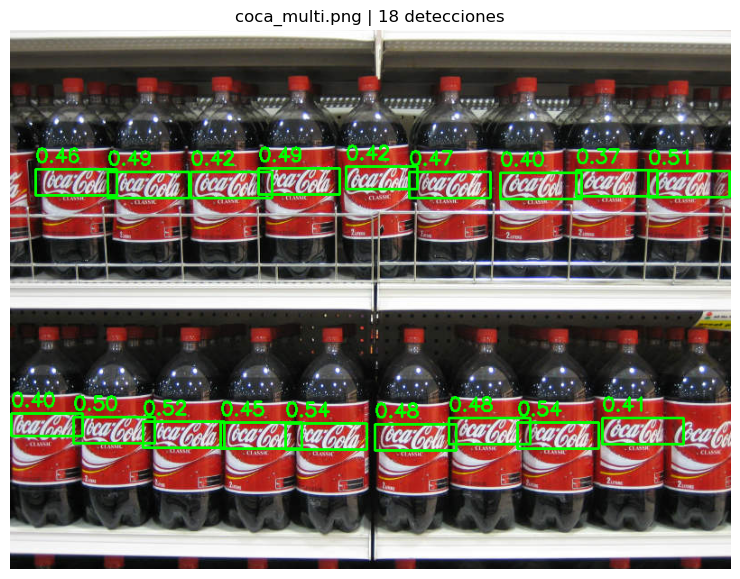

In [ ]:
multi_path = next(
    p for p in image_paths
    if p.name == "coca_multi.png"
)

multi_img = cv2.imread(str(multi_path))

# Detectamos múltiples instancias del logo en la imagen
detections_multi = detect_multiple(
    multi_img,
    template,
    threshold=THRESHOLD_MULTI,
    scales=SCALES_MULTI,
    nms_threshold=NMS_THRESHOLD
)

print("Cantidad de detecciones:", len(detections_multi))

show_detections(
    multi_img,
    detections_multi,
    title=f"coca_multi.png | {len(detections_multi)} detecciones"
)


Se aplica **Non-Maximum Suppression (NMS)** para eliminar bounding boxes superpuestas que corresponden al mismo logo.


## 6. Punto 3 - Generalización


### Generalización

Para generalizar el detector se combinan las dos estrategias anteriores.

Primero se buscan múltiples coincidencias utilizando template matching sobre la imagen en escala de grises. Luego se eliminan detecciones con tamaños inconsistentes.

Si no se obtiene un conjunto de múltiples detecciones consistentes, se utiliza el detector individual basado en gradientes Sobel.

In [ ]:
def filter_by_size(detections, min_ratio=0.5, max_ratio=1.8):
    if not detections:
        return []

    # tomar como referencia la detección de mayor score
    best = max(detections, key=lambda d: d["score"])

    # calcular el área de la detección de referencia
    x1, y1, x2, y2 = best["box"]
    best_area = (x2 - x1) * (y2 - y1)

    filtered = []

    # iteramos sobre todas las detecciones y filtramos según el área relativa
    for det in detections:
        x1, y1, x2, y2 = det["box"]
        area = (x2 - x1) * (y2 - y1)

        area_ratio = area / best_area

        if min_ratio <= area_ratio <= max_ratio:
            filtered.append(det)

    # retornamos las detecciones filtradas
    return filtered

In [13]:
def detect_general(
    image,
    template,
    threshold,
    scales_multi,
    scales_single
):

    # 1. Buscar múltiples detecciones
    detections = detect_multiple(
        image,
        template,
        threshold=threshold,
        scales=scales_multi,
        nms_threshold=NMS_THRESHOLD
    )

    # Eliminar candidatos de tamaño muy diferente
    detections = filter_by_size(
        detections,
        min_ratio=0.5,
        max_ratio=1.8
    )

    # Si quedaron varias detecciones consistentes,
    # consideramos que realmente es una imagen multi
    if len(detections) > 1:
        return detections

    # 2. Deteccion unica
    box, score, scale = detect_one(
        image,
        template,
        scales=scales_single
    )

    if box is None:
        return []

    return [{
        "box": box,
        "score": score
    }]

COCA-COLA-LOGO.jpg   | detecciones = 1


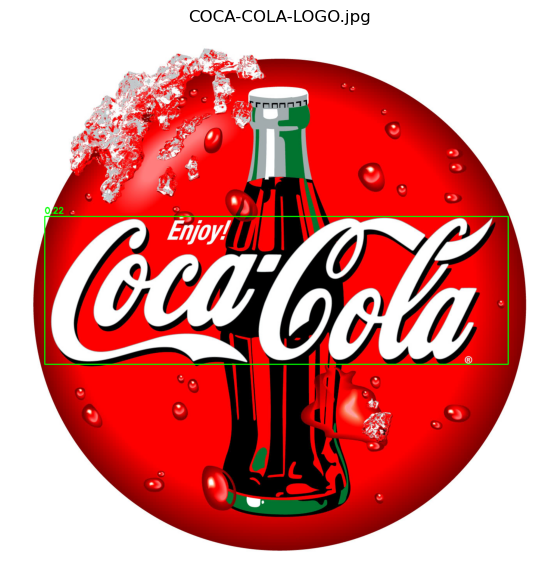

coca_logo_1.png      | detecciones = 1


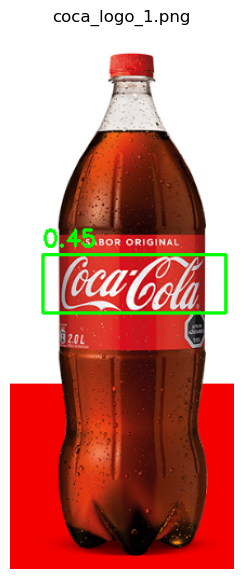

coca_logo_2.png      | detecciones = 1


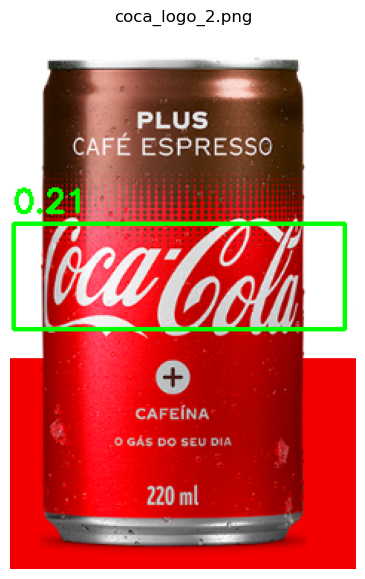

coca_multi.png       | detecciones = 18


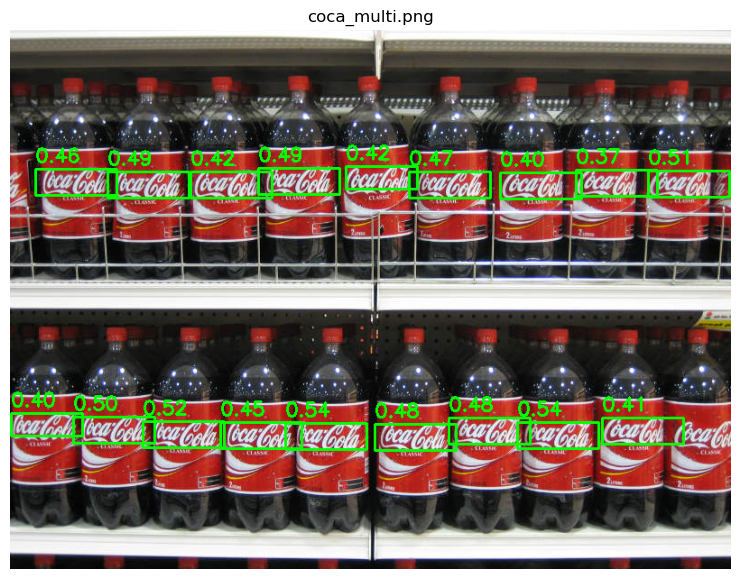

coca_retro_1.png     | detecciones = 1


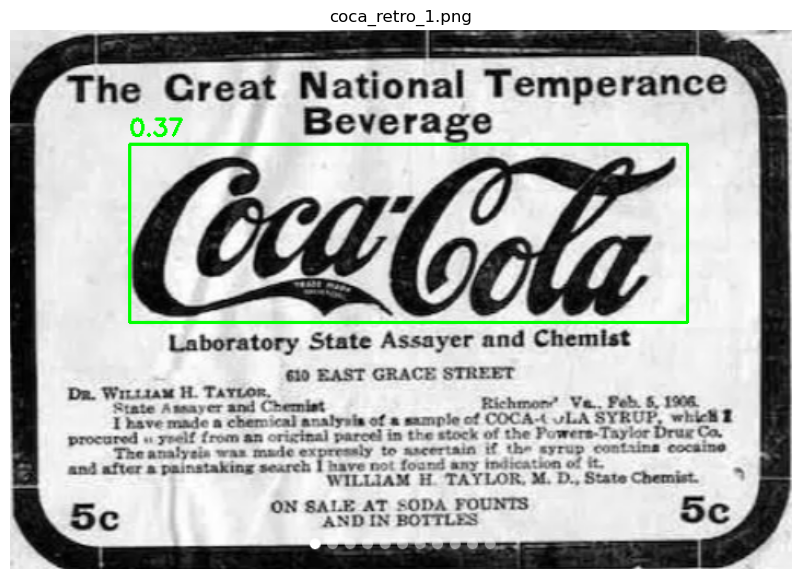

coca_retro_2.png     | detecciones = 1


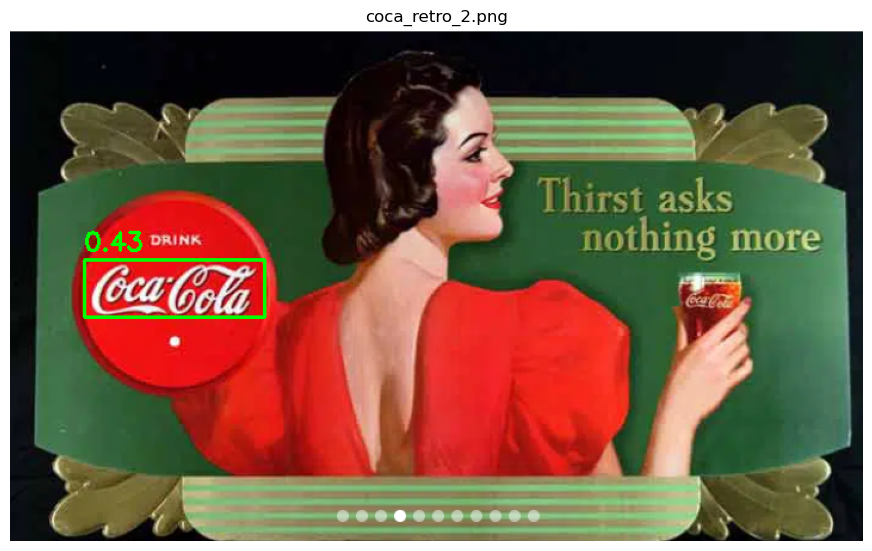

logo_1.png           | detecciones = 1


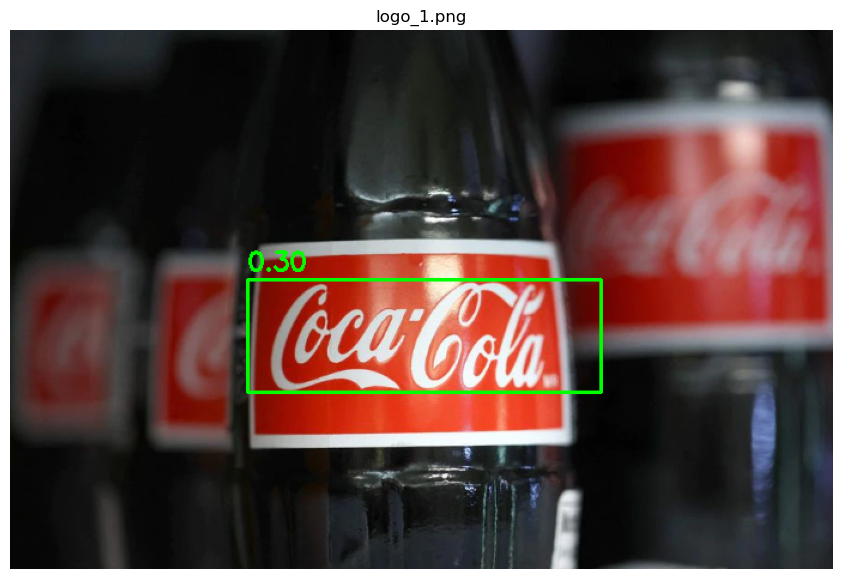

In [ ]:
for path in image_paths:

    image = cv2.imread(str(path))

    # Detectamos el logo en la imagen, considerando tanto detecciones múltiples como únicas
    detections = detect_general(
        image,
        template,
        threshold=THRESHOLD_MULTI,
        scales_multi=SCALES_MULTI,
        scales_single=SCALES_SINGLE
    )

    print(
        f"{path.name:20s} | "
        f"detecciones = {len(detections)}"
    )

    show_detections(
        image,
        detections,
        title=path.name
    )

## Conclusiones

Se implementó un detector basado en template matching multiescala para localizar el logo de Coca-Cola en imágenes con distintas escalas y apariencias.

Para la detección individual se utilizó la magnitud del gradiente mediante Sobel, ya que resultó más robusta frente a variaciones de contraste y estilo del logo.

Para la detección múltiple se utilizó escala de grises con suavizado Gaussiano, junto con un threshold de correlación y Non-Maximum Suppression (NMS) para eliminar detecciones repetidas.

En la etapa de generalización se combinaron ambas estrategias y se agregó un filtro por tamaño para eliminar candidatos inconsistentes.

El método logra detectar correctamente el logo en las imágenes individuales y múltiples instancias en `coca_multi.png`, mostrando en todos los casos el bounding box y el nivel de confianza.